# 08 Model Evaluation

## Purpose
Combine model metrics, compare methods, and create report-ready evaluation tables and figures.

## Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"
for directory in [FIGURES_DIR, TABLES_DIR, MODELS_DIR, DATA_DIR / "processed"]:
    directory.mkdir(parents=True, exist_ok=True)

import pandas as pd

from src.visualization import plot_model_comparison

## Data loading

In [2]:
metric_files = [
    TABLES_DIR / "06_baseline_model_metrics.csv",
    TABLES_DIR / "07_progression_model_metrics.csv",
]
metrics = pd.concat([pd.read_csv(path) for path in metric_files if path.exists()], ignore_index=True)
metrics

,model,target,accuracy,precision,recall,f1,roc_auc,average_precision
0,logistic_regression,future_hospitalization,0.645480,0.076797,0.616535,0.136581,0.686321,0.087288
1,dummy_most_frequent,future_hospitalization,0.954520,0.000000,0.000000,0.000000,0.500000,0.045480
2,random_forest,multimorbidity_progression,0.781160,0.715243,0.825050,0.766232,0.860540,0.761737
3,logistic_regression,multimorbidity_progression,0.768581,0.695692,0.831235,0.757448,0.853368,0.764152
4,dummy_most_frequent,multimorbidity_progression,0.565297,0.000000,0.000000,0.000000,0.500000,0.434703


## Main evaluation

In [3]:
if metrics.empty:
    raise FileNotFoundError("Run notebooks 06 and 07 first to create model metric files.")

metrics_sorted = metrics.sort_values(["target", "roc_auc", "f1"], ascending=[True, False, False])
metrics_sorted

,model,target,accuracy,precision,recall,f1,roc_auc,average_precision
0,logistic_regression,future_hospitalization,0.645480,0.076797,0.616535,0.136581,0.686321,0.087288
1,dummy_most_frequent,future_hospitalization,0.954520,0.000000,0.000000,0.000000,0.500000,0.045480
2,random_forest,multimorbidity_progression,0.781160,0.715243,0.825050,0.766232,0.860540,0.761737
3,logistic_regression,multimorbidity_progression,0.768581,0.695692,0.831235,0.757448,0.853368,0.764152
4,dummy_most_frequent,multimorbidity_progression,0.565297,0.000000,0.000000,0.000000,0.500000,0.434703


In [4]:
best_by_target = metrics_sorted.groupby("target").head(1).reset_index(drop=True)
best_by_target

,model,target,accuracy,precision,recall,f1,roc_auc,average_precision
0,logistic_regression,future_hospitalization,0.64548,0.076797,0.616535,0.136581,0.686321,0.087288
1,random_forest,multimorbidity_progression,0.78116,0.715243,0.825050,0.766232,0.860540,0.761737


(<Figure size 960x600 with 1 Axes>,
 <Axes: title={'center': 'Model Comparison by F1'}, xlabel='F1', ylabel='Model'>)

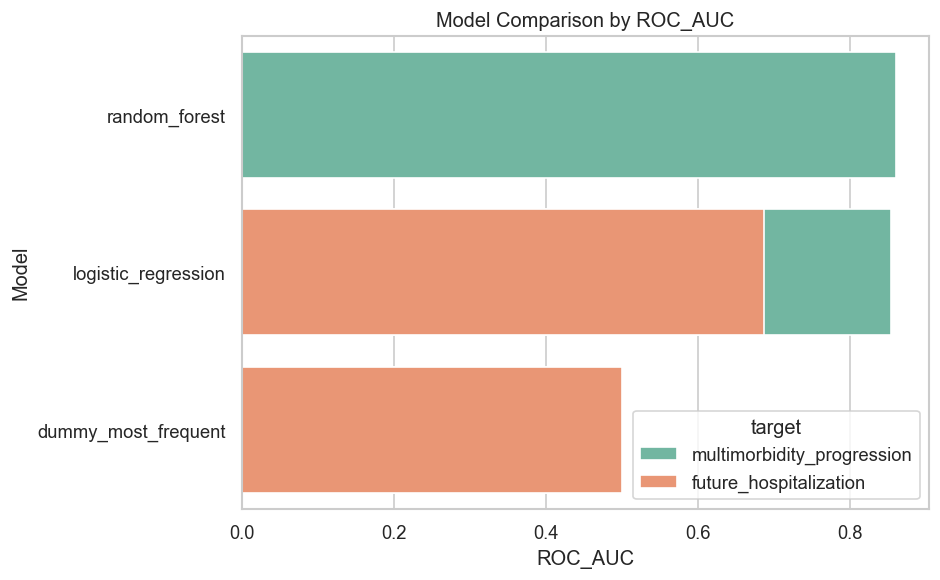

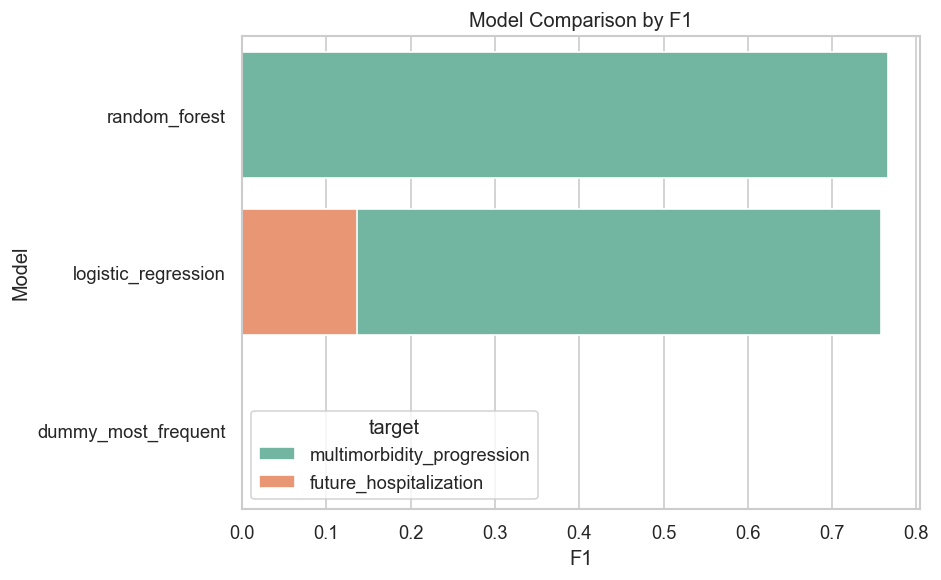

In [5]:
plot_model_comparison(metrics_sorted, metric="roc_auc", path=FIGURES_DIR / "08_model_comparison_roc_auc.png")
plot_model_comparison(metrics_sorted, metric="f1", path=FIGURES_DIR / "08_model_comparison_f1.png")

## Key findings

- Models should be compared using several metrics, not accuracy alone.
- ROC-AUC evaluates ranking quality, while recall and F1 help interpret detection of higher-risk patients.
- The final report can use this notebook to justify which model is strongest for each target.

## Saved outputs

In [6]:
metrics_sorted.to_csv(TABLES_DIR / "08_all_model_metrics.csv", index=False)
best_by_target.to_csv(TABLES_DIR / "08_best_models_by_target.csv", index=False)
print("Saved combined evaluation tables and comparison figures.")

Saved combined evaluation tables and comparison figures.
